In [218]:
import numpy as np
import scipy.stats as stats
import scipy.special as special
import matplotlib.pyplot as plt

### Standard $z$-scores.

Let
$$
z_{\alpha} = \operatorname{ppf}_{N(0, 1)}(1 - \alpha).
$$
Then
$$
\mathbb{P}( -z_{\alpha/2}<Z< z_{\alpha/2} ) = \alpha
$$

In [ ]:
z = stats.norm.ppf(1 - 0.05 / 2)
print(f"z_0.025 = {z:.3f}")
assert np.isclose(stats.norm().cdf(z) - stats.norm.cdf(-z), 0.95)

z_0.025 = 1.960


Suppose $X\sim N(\mu,\sigma^2)$ with $\mu$ unknown but $\sigma^2$ known.

Then
$$
\frac{\mu - X}{\sigma}\sim N(0, 1).
$$

Therefore,
$$
\mathbb{P}\left( -z_{\alpha/2} < \frac{\mu - X}{\sigma} < z_{\alpha/2}\right) = \alpha.
$$

Equivalently,
$$
\mathbb{P}\left( X - z_{\alpha/2}\sigma < \mu < X + z_{\alpha/2}\sigma\right) = \alpha.
\tag{$*$}
$$

We call the interval $[X - z_{\alpha/2}\sigma, X + z_{\alpha/2}\sigma]$ the $100\alpha\%$-confidence interval for $\mu$.

Let's verify $(*)$ by simulation. Specifically, let's show that if $X_0,\ldots,X_m$ is a random sample from $N(\mu,\sigma)$, then 95% of the confidence intervals contain $\mu$.

In [ ]:
mu = 5
sigma = 2
m = 100_000
x = stats.norm.rvs(loc=mu, scale=sigma, size=m)
z = stats.norm.ppf(1 - 0.05 / 2)
a = x - z * sigma
b = x + z * sigma
np.mean((a < mu) & (mu < b))  # should be about 0.95

np.float64(0.95063)

The above assumption that $\sigma$ is known is crucial because otherwise we can't form the confidence intervals.

We can also do some business in a situation where we can estimate $\sigma$.

Let
$$
X_0,\ldots, X_{n-1}\sim N(\mu,\sigma^2)
$$
with both $\mu$ and $\sigma$ unknown.

Then the sample mean $\bar{X}_n$ is also normally distributed:
$$
\bar{X}_n = \frac1n\sum_{i < n}X_i \sim N\left(\mu, \frac{\sigma^2}{n}\right).
$$

Approximate $\sigma^2$ by the sample variance:
$$
s^2 = \frac1{n-1}\sum_{i < n}(X_i - \bar{X}_n)^2.
$$

Question: How often does the interval
$$
\left[\bar{X}_n - z_{\alpha/2}\frac{s}{\sqrt{n}}, \bar{X}_n + z_{\alpha/2}\frac{s}{\sqrt{n}}\right]
$$
contain $\mu$?

$$
Z = \frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}}
$$

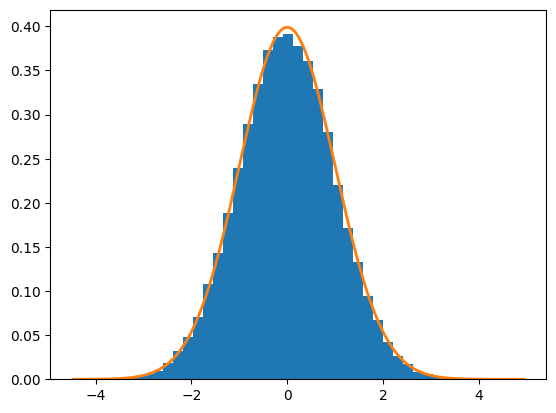

In [ ]:
mu = 5
sigma = 2
n = 3
m = 100_000
x = stats.norm.rvs(loc=mu, scale=sigma, size=(m, n))

xbar = x.mean(axis=1)
z = (xbar - mu) / (sigma / np.sqrt(n))
plt.hist(z, bins=41, density=True)
u = np.linspace(*plt.xlim(), 1000)
plt.plot(u, stats.norm.pdf(u), lw=2)
plt.show()

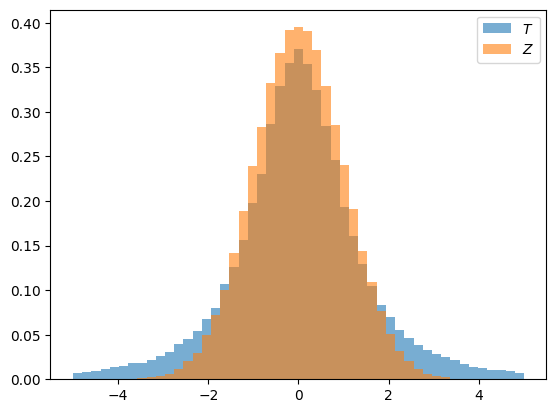

In [ ]:
mu = 5
sigma = 2
n = 3
m = 100_000
x = stats.norm.rvs(loc=mu, scale=sigma, size=(m, n))

xbar = x.mean(axis=1)
s = x.std(axis=1, ddof=1)
t = (xbar - mu) / (s / np.sqrt(n))
z = (xbar - mu) / (sigma / np.sqrt(n))
bins = np.linspace(-5, 5, 50)
plt.hist(t, density=True, bins=bins, alpha=0.6, label="$T$")
plt.hist(z, density=True, bins=bins, alpha=0.6, label="$Z$")
plt.legend()
plt.show()

In [ ]:
mu = 5
sigma = 2
n = 3
m = 100_000
x = stats.norm.rvs(loc=mu, scale=sigma, size=(m, n))
z = stats.norm.ppf(1 - 0.05 / 2)

xbar = x.mean(axis=1)
s = x.std(axis=1, ddof=1)

a = xbar - z * s / np.sqrt(n)
b = xbar + z * s / np.sqrt(n)
np.mean((a < mu) & (mu < b))  # Should be about 0.95?

np.float64(0.81208)

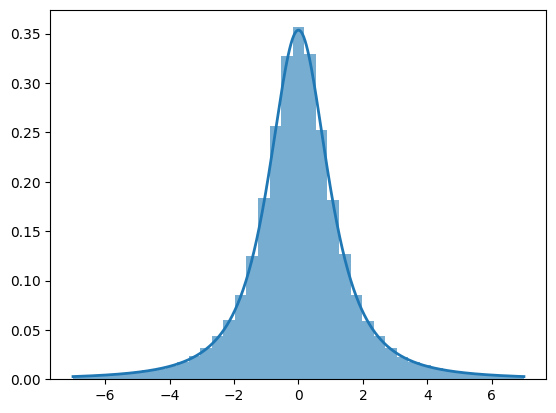

In [ ]:
mu = 5
sigma = 2
n = 3
m = 100_000
x = stats.norm.rvs(loc=mu, scale=sigma, size=(m, n))

xbar = x.mean(axis=1)
s = x.std(axis=1, ddof=1)
t = (xbar - mu) / (s / np.sqrt(n))
bins = np.linspace(-7, 7, 40)
plt.hist(t, density=True, bins=bins, alpha=0.6)
u = np.linspace(-7, 7, 1000)
plt.plot(u, stats.t.pdf(u, df=n - 1), "C0", lw=2)
plt.show()

The problem goes away for larger $n$ because of asymptotic normality.

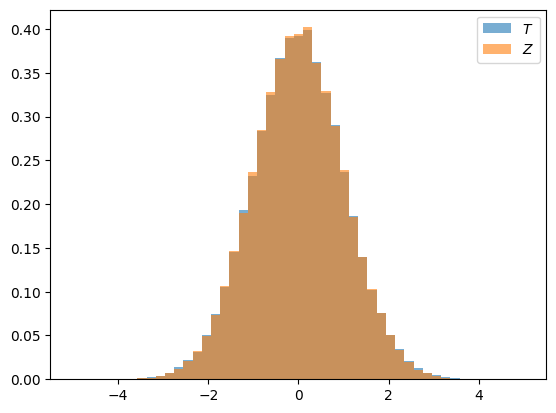

In [ ]:
mu = 5
sigma = 2
n = 100
m = 100_000
x = stats.norm.rvs(loc=mu, scale=sigma, size=(m, n))

xbar = x.mean(axis=1)
s = x.std(axis=1, ddof=1)
t = (xbar - mu) / (s / np.sqrt(n))
z = (xbar - mu) / (sigma / np.sqrt(n))
bins = np.linspace(-5, 5, 50)
plt.hist(t, density=True, bins=bins, alpha=0.6, label="$T$")
plt.hist(z, density=True, bins=bins, alpha=0.6, label="$Z$")
plt.legend()
plt.show()

In [ ]:
mu = 5
sigma = 2
n = 100
m = 100_000
x = stats.norm.rvs(loc=mu, scale=sigma, size=(m, n))
z = stats.norm.ppf(1 - 0.05 / 2)

xbar = x.mean(axis=1)
s = x.std(axis=1, ddof=1)

a = xbar - z * s / np.sqrt(n)
b = xbar + z * s / np.sqrt(n)
np.mean((a < mu) & (mu < b))  # Should be about 0.95?

np.float64(0.94781)

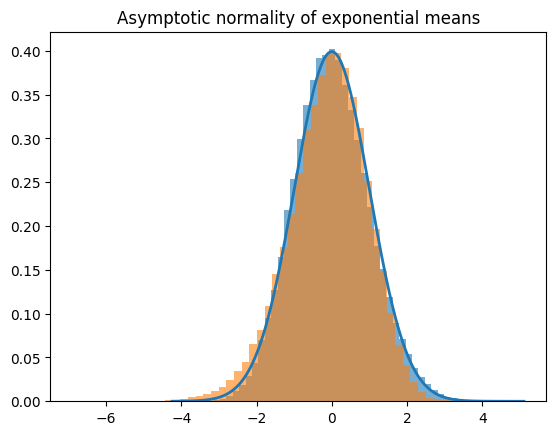

In [ ]:
mu = stats.expon.mean()
sigma = stats.expon.std()
x = stats.expon.rvs(size=(m, n))
n = 100
m = 100_000
xbar = x.mean(axis=1)
s = x.std(axis=1, ddof=1)
z = (xbar - mu) / (sigma / np.sqrt(n))
plt.hist(z, bins=50, density=True, alpha=0.6)
u = np.linspace(*plt.xlim(), 1000)
plt.plot(u, stats.norm.pdf(u), "C0", lw=2)
t = (xbar - mu) / (s / np.sqrt(n))
plt.hist(t, bins=50, density=True, alpha=0.6)
plt.title("Asymptotic normality of exponential means")
plt.show()

In [177]:
n = 10
p0 = 0.5
p1 = 0.7
y = np.arange(n + 1)
stats.binom.pmf(y, n=n, p=p0).round(4)

array([0.001 , 0.0098, 0.0439, 0.1172, 0.2051, 0.2461, 0.2051, 0.1172,
       0.0439, 0.0098, 0.001 ])

In [ ]:
lr = stats.binom.pmf(y, n=n, p=p0) / stats.binom.pmf(y, n=n, p=p1)
for i in range(11):
    print(f"{lr[i]:.4f}")

165.3817
70.8779
30.3762
13.0184
5.5793
2.3911
1.0248
0.4392
0.1882
0.0807
0.0346


In [ ]:
def lr(y):
    return stats.binom.pmf(y, n=n, p=p0) / stats.binom.pmf(y, n=n, p=p1)


y = stats.binom.rvs(n=n, p=p0, size=100000)
np.mean(lr(y) < 1)

np.float64(0.17127)

In [207]:
y = np.arange(n + 1)
a = stats.binom.pmf(y, n=n, p=p0)

In [210]:
np.cumsum(a)

array([9.76562500e-04, 1.07421875e-02, 5.46875000e-02, 1.71875000e-01,
       3.76953125e-01, 6.23046875e-01, 8.28125000e-01, 9.45312500e-01,
       9.89257813e-01, 9.99023438e-01, 1.00000000e+00])

In [219]:
y = 7
stats.binom.logpmf(y, n=n, p=p0)

np.float64(-2.143980062817406)

In [ ]:
y = 7

A0 = np.log(p0) - np.log(1 - p0)
B0 = np.log(special.binom(n, y)) + n * np.log(1 - p0)
assert np.isclose(A0 * y + B0, stats.binom.logpmf(y, n=n, p=p0))

A1 = np.log(p1) - np.log(1 - p1)
B1 = np.log(special.binom(n, y)) + n * np.log(1 - p1)
assert np.isclose(A1 * y + B1, stats.binom.logpmf(y, n=n, p=p1))

In [ ]:
y = np.arange(n + 1)

A0 = np.log(p0) - np.log(1 - p0)
A1 = np.log(p1) - np.log(1 - p1)
A = A0 - A1

B0 = n * np.log(1 - p0)
B1 = n * np.log(1 - p1)
B = B0 - B1

L = stats.binom.logpmf(y, n=n, p=p0) - stats.binom.logpmf(y, n=n, p=p1)
assert np.allclose(A * y + B, L)

Let $\operatorname{LR}$ be the likelihood ratio statistic:
$$
\operatorname{LR} = \frac{\displaystyle\binom{n}{y}p_0^y(1 - p_0)^{n - y}}
{\displaystyle\binom{n}{y}p_1^y(1 - p_1)^{n - y}}
$$
Suppose $n=10$, $p_0=0.5$, and $p_1=0.7$.
For which values of $y$ does the likelihood ratio test that rejects for $\operatorname{LR}<1$ reject?

In [243]:
A, B

(np.float64(-0.8472978603872034), np.float64(5.108256237659906))

In [239]:
L

array([ 5.10825624,  4.26095838,  3.41366052,  2.56636266,  1.7190648 ,
        0.87176694,  0.02446908, -0.82282879, -1.67012665, -2.51742451,
       -3.36472237])

Decision function:
$$
\delta:\mathbb{R}\longrightarrow \{0, 1\}
$$

We call $\{x: \delta(x)=0\}$ the **acceptance region** and $\{x:\delta(x)=1\}$ the **rejection region**.

Let $\alpha$ be the false-positive rate
$$
\alpha = \mathbb{P}[\delta(X)=1\mid \theta=\theta_0]
$$l

Suppose we're testing the null hypothesis
$$
H_0:\theta = \theta_0
$$
for $X\sim N(\theta, \sigma^2)$ with $\sigma^2$ known.

For $x\in\mathbb{R}$ and $\xi > 0$, define
$$
\delta_{\xi}(x) = \begin{cases}1&\text{if $\left|\dfrac{x-\theta_0}{\sigma}\right|\gt\xi$},\\0&\text{otherwise.}\end{cases}
$$

The test $\delta_\xi$ partitions $\mathbb{R}$ into an **acceptance region**,
$$
A_\xi = \{x : \delta_\xi(x)=0\}
$$
and a **rejection region**,
$$
R_\xi = \{x : \delta_\xi(x)=1\}.
$$

Significance level of $\delta_\xi$:
$$
\begin{aligned}
\alpha_\xi &= \mathbb{P}_{X\sim N(\theta_0,\sigma^2)}[\delta_\xi(X) = 1]\\
&= \mathbb{P}_{X\sim N(\theta_0,\sigma^2)}\left[\left|\dfrac{X-\mu}{\sigma}\right|\gt\xi\right]\\
&= \mathbb{P}_{Z\sim N(0, 1)}\left[|Z| > \xi\right]\\
&= 2(1 - \operatorname{cdf}_{N(0, 1)}(\xi))
\end{aligned}
$$


Conversely, given a significance level $\alpha$, choose $\xi_\alpha$ such that
$$
2(1 - \operatorname{cdf}_{N(0, 1)}(\xi_\alpha)) = \alpha.
$$
Equivalently,
$$
\xi_\alpha = \operatorname{ppf}_{N(0, 1)}\left(1 - \frac\alpha2\right)
$$


Define
$$
C(X) = \{\theta : X\in A(\theta)\}
$$

Let $\mathscr{F}=\{f_\theta : \theta\in\Theta\}$ be a parametric family of distributions on $\mathbb{R}^n$.

A **hypothesis testing procedure** for $\mathscr{F}$ is a pair $(t,\delta)$, where
- $t$ is a **test function**,
$$
t:\Theta\times \mathbb{R}^n\to\mathbb{R},\qquad
(\theta,x)\mapsto t_\theta(x),
$$
- $\delta$ is a **decision function**, $\delta:\mathbb{R}\to\{0, 1\}$.

Confidence region:
$$
C(x) = \{\theta\in\Theta : \delta(t_\theta(x))=0\}
$$


$$
\begin{aligned}
\mathbb{P}_{X\sim f_{\theta}}[\theta\in C(t_\theta(X))] &= \mathbb{P}_{X\sim f_{\theta}}[t_\theta(X)\in A]\\
&= \mathbb{P}_{X\sim f_{\theta}}[\delta(t_\theta(X))=0] = 1 - \alpha
\end{aligned}
$$


Assume that the distribution of $t_\theta(X)$ for $X\sim f_\theta$ is independent of $\theta$.
Define the significance leve $\alpha$ of $(t, \delta)$ by 
$$
\alpha = \mathbb{P}_{X\sim f_{\theta}}[\delta(t_\theta(X))=1].
$$
Then
$$
\begin{aligned}
\mathbb{P}_{X\sim f_{\theta}}[\theta\in C(t_\theta(X))]
&= \mathbb{P}_{X\sim f_{\theta}}[\delta(t_\theta(X))=0]\\
&= 1 - \alpha
\end{aligned}
$$

### One-sample $z$-test

Let $f_\theta$ be the normal density on $\mathbb{R}^n$ with mean $\theta\mathbf{1}\in\mathbb{R}^n$ and known variance $\sigma^2I$.

For $x\in\mathbb{R}$, define
$$
\bar{x} = \frac1n\sum_{i \lt n}x_i,\qquad
t_\theta(x) = \frac{\bar{x} - \theta}{\sigma/\sqrt{n}}.
$$

If $X\sim f_\theta$, then
$$
t_\theta(X)\sim N(0, 1).
$$
In particular, the distribution of $t_\theta(X)$ is independent of $\theta$, as required.

Let $\tau > 0$ and define
$$
\delta_\tau(t) = \begin{cases}
1&\text{if $|t| > \tau$,}\\
0&\text{otherwise.}
\end{cases}
$$

We have:
$$
\begin{aligned}
C(x) &= \{\theta\in\Theta : \delta_\tau(t_\theta(x))=0\}\\
&= \left\{\theta\in\Theta : |t_\theta(x)| \leq \tau \right\}\\
&=[\bar{x} - \tau\sigma, \bar{x} + \tau\sigma]\\
\end{aligned}
$$

Since $t_\theta(X)\sim N(0, 1)$, the significance level of the test is
$$
\mathbb{P}_{Z\sim N(0,1)}[|Z| > \tau] = 2(1 - \operatorname{cdf}_{N(0, 1)}(\tau)) = 2\operatorname{sf}_{N(0, 1)}(\tau).
$$

If we choose a significance level $\alpha$ in advance, we can define $\tau=\tau_{\alpha/2}$ by
$$
\operatorname{sf}_{N(0, 1)}(\tau_{\alpha/2}) = \alpha/2,
$$
in which case the confidence intervals take the form
$$
C(x) = [\bar{x} - \tau_{\alpha/2}\sigma, \bar{x} + \tau_{\alpha/2}\sigma]
$$

### One-sample $t$-test

Let $f_\theta$ be the normal density on $\mathbb{R}^n$ with mean $\theta\mathbf{1}\in\mathbb{R}^n$ and unknown variance $\sigma^2I$.

For $x\in\mathbb{R}$, define
$$
\begin{aligned}
\bar{x} &= \frac1n\sum_{i \lt n}x_i\\
s^2 &= \frac1{n-1}\sum_{i \lt n}(x_i - \bar{x}),\\
t_\theta(x) &= \frac{\bar{x} - \theta}{s/\sqrt{n}}.
\end{aligned}
$$


If $X\sim f_\theta$, then
$$
t_\theta(X)\sim t_{n - 1}.
$$
In particular, the distribution of $t_\theta(X)$ is independent of $\theta$, as required.

Let $\tau > 0$ and define
$$
\delta_\tau(t) = \begin{cases}
1&\text{if $|t| > \tau$,}\\
0&\text{otherwise.}
\end{cases}
$$

We have:
$$
\begin{aligned}
C(x) &= \{\theta\in\Theta : \delta_\tau(t_\theta(x))=0\}\\
&= \left\{\theta\in\Theta : |t_\theta(x)| \leq \tau \right\}\\
&=[\bar{x} - \tau\sigma, \bar{x} + \tau\sigma]\\
\end{aligned}
$$

Since $t_\theta(X)\sim t_{n-1}$, the significance level of the test is
$$
\mathbb{P}_{Z\sim N(0,1)}[|Z| > \tau] = 2(1 - \operatorname{cdf}_{t_{n-1}}(\tau)) = 2\operatorname{sf}_{t_{n-1}}(\tau).
$$

If we choose a significance level $\alpha$ in advance, we can define $\tau=\tau_{\alpha/2}$ by
$$
\operatorname{sf}_{t_{n-1}}(\tau_{\alpha/2}) = \alpha/2,
$$
in which case the confidence intervals take the form
$$
C(x) = [\bar{x} - \tau_{\alpha/2}\sigma, \bar{x} + \tau_{\alpha/2}\sigma]
$$

Let $\mathscr{F}=\{f_\theta : \theta\in\Theta\}$ be a parametric family of distributions on $\mathscr{X}$.

Let
$$
\delta:\Theta\times\mathscr{X}\to\mathbb{R}.
$$
Call $\delta$ a **decision function** if
$$
1 - \alpha = \mathbb{P}_{X\sim f_\theta}[\delta(\theta, X)= 0],
$$
is independent of $\theta\in\Theta$,
in which case $\alpha$ is called the **significance level** of $\delta$.


Define the **acceptance region** $A(\theta)$ and the **confidence region** $C(x)$ associated to $\delta$ by
$$
A(\theta) = \{x\in\mathscr{X} : \delta(\theta, x) = 0\}
\quad\text{and}\quad
C(x) = \{\theta\in\Theta : \delta(\theta, x)=0\}.
$$

Then
$$
A(\theta) = \{x\in\mathscr{X}: \theta\in C(x)\}
\quad\text{and}\quad
C(x) = \{\theta\in\Theta : x\in A(\theta)\}.
$$

Moreover,
$$
\mathbb{P}_{X\sim f_\theta}[X\in A(\theta)] = \mathbb{P}_{X\sim f_\theta}[\theta\in C(X)] = 1 - \alpha.
$$

### Likelihood ratio test (LRT)

Let $\mathscr{F}=\{f_\theta : \theta\in\Theta\}$ be a parametric family of distributions on $\mathscr{X}$.
Let $\Theta_0\subseteq \Theta$.

Define the **likelihood ratio statistic** $\Lambda(x)$ by
$$
\Lambda(\theta, x) = \frac{f_{\theta}(x)}{\sup_{\varphi\in\Theta}f_\varphi(x)}.
$$

For $0\lt c \lt 1$, define
$$
\delta(\theta, x)=\begin{cases}1&\text{if $\Lambda(\theta, x) < c$,}\\
0&\text{otherwise.}
\end{cases}
$$

#### LRT for normal means

Using the identity
$$
\sum_{i \lt n} (x_i - \theta)^2 = \sum_{i \lt n} (x_i - \bar{x})^2 + n(\bar{x} - \theta)^2,
$$
we get:
$$
\begin{aligned}
\lambda(\theta, x) &= -2\log\Lambda(\theta, x)\\
&= \frac1{\sigma^2}\left(\sum_{i \lt n} (x_i - \theta)^2 - \sum_{i\lt n}(x_i - \bar{x})^2\right)\\
&= \frac{(\bar{x} - \theta)^2}{\sigma^2/n}\\
\end{aligned}
$$

Since
$$
\Lambda(\theta, x) \lt c \Longleftrightarrow \lambda(\theta, x) \gt -2\log c,
$$
we can consider decision functions of the form
$$
\delta(\theta, x)=\begin{cases}1&\text{if $\lambda(\theta, x) > d$,}\\
0&\text{otherwise,}
\end{cases}
$$
where $d > 0$.

If $X\sim N(\theta\mathbf{1},\sigma^2I)$ with $\sigma^2$ known, then
$$
\frac{\bar{X} - \theta}{\sigma/\sqrt{n}}\sim N(0, 1),
$$
implying
$$
\lambda(\theta, X) = \left(\frac{\bar{X} - \theta}{\sigma/\sqrt{n}}\right)^2\sim \chi^2_1.
$$

In particular, the distribution of $\lambda(\theta, X)$ is independent of $\theta$ if $X\sim N(\theta\mathbf{1},\sigma^2I)$ with $\sigma^2$ known.
Therefore, $\delta$ is a decision function.

Use the identity
$$
\sum_{i \lt n} (x_i - \theta)^2 = \sum_{i \lt n} (x_i - \bar{x})^2 + n(\bar{x} - \theta)^2.
$$

$$
\begin{aligned}
(n - 1)\frac{s^2}{\sigma^2} &= \frac1{\sigma^2}\sum_{i \lt n}(x_i - \bar{x})^2\\
&= \sum_{i\lt n}\left(\frac{x_i - \theta}{\sigma}\right)^2 - \left(\frac{\bar{x} - \theta}{\sigma/\sqrt{n}}\right)^2\\
&= \sum_{i\lt n}z_i^2 - z^2
\end{aligned}
$$

